In [21]:
import os
import win32com.client as win32
from y_n import y_n_distribution
from upsilon_n import upsilon_n
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

In [22]:
from models_FTS.components import parafins, olefins, others

In [23]:
hysys = win32.Dispatch("HYSYS.Application")

In [24]:
os.chdir("Z:\\uem\\Doutorado\\Ensaios\\SAF\\SAF_8_08_08_2025\\SAF_kinetics_paper_code")
path = "hysys_simulation_parity"
hy_path = os.path.abspath(path)

In [5]:
hy_case = hysys.Application.ActiveDocument
if hy_case == None:
    hy_case = hysys=SimulationCase.Open(hy_path)

hy_case.Visible = 1

In [6]:
hy_solver = hy_case.Solver
hy_int = hy_solver.Integrator

hy_f = hy_case.Flowsheet

hy_package = hy_f.FluidPackage

In [7]:
hy_ms = hy_f.MaterialStreams
hy_es = hy_f.EnergyStreams

In [8]:
hy_case.Solver.CanSolve = False

In [9]:
reactor = hy_case.Flowsheet.Operations.Item('PFR-100')

In [10]:
reactor.TotalVolume.GetValue('mL')

7.880000000000001

In [11]:
n_parafins = {}
for i, parafin in enumerate(parafins):
    n = i + 1
    if n not in [4, 5, 6, 7, 8, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]:
        n_parafins[parafin] = n

n_olefins = {}
for i, olefin in enumerate(olefins):
    n = i + 2
    if n not in [3, 4, 5, 6, 7, 8]:
        n_olefins[olefin] = n

N = list(set(list(n_parafins.values()) + list(n_olefins.values())))

In [12]:
rxn_set = hy_case.BasisManager.ReactionPackageManager.ReactionSets.Item('FTS')

In [25]:
kinetic_data = pd.read_pickle('kinetic_data.pkl')

In [26]:
F0 = kinetic_data.F_H2_e_mol_s + kinetic_data.F_CO_e_mol_s
F0.mean()

np.float64(0.00013599742941543852)

In [14]:
for i in kinetic_data.index:
    T = kinetic_data.T_R_K[i]
    P = kinetic_data.P_abs_Pa[i]
    F_in_H2 =  kinetic_data.F_H2_e_mol_s[i]
    F_in_CO =  kinetic_data.F_CO_e_mol_s[i]
    H2_CO = F_in_H2 / F_in_CO
    F_in = F_in_H2 + F_in_CO
    y_in_H2 = F_in_H2 / F_in
    y_in_CO = F_in_CO / F_in
    
    F0 = hy_ms.Item('F0')
    P0 = hy_ms.Item('P0')
    
    F0_molar_frac = list(F0.ComponentMolarFractionValue)
    
    F0_molar_frac[F0.ComponentIndices('Hydrogen')[0]] = y_in_H2 
    F0_molar_frac[F0.ComponentIndices('CO')[0]] = y_in_CO
    
    F0.ComponentMolarFractionValue = F0_molar_frac
    
    F0.MolarFlow.SetValue(F_in, 'gmole/s')
    F0.Pressure.SetValue(P, 'Pa')
    F0.Temperature.SetValue(T, 'K')
    P0.Temperature.SetValue(T, 'K')
    
    y_n_dist = y_n_distribution(T, H2_CO, N)

    # must multiply reaction rate by correction factor below
    # because hysys bases reaction rate only on the gas phase, not the catalyst volume
    vol_cat_to_vol_gas =  (1 / reactor.VoidFraction) - 1 # m³ cat / m³ gas
    overall_freq_fact = 11153 # kmol / s / m³ cat / Pa²
    
    for component, n in n_parafins.items():
        freq_fact = n * y_n_dist[n] * upsilon_n(n) * overall_freq_fact * vol_cat_to_vol_gas # kmol / s / m³ gas / Pa²
        rxn_set.ReactionPackage.Reactions.Item(component).ForwardFrequencyFactor = freq_fact
    
    for component, n in n_olefins.items():
        freq_fact = n * y_n_dist[n] * ( 1 - upsilon_n(n) ) * overall_freq_fact * vol_cat_to_vol_gas # kmol / s / m³ / Pa²
        rxn_set.ReactionPackage.Reactions.Item(component).ForwardFrequencyFactor = freq_fact
    
    # solve
    # 3. Ligar o solver
    hy_case.Solver.CanSolve = True
    
    # 4. Aguardar a convergência
    while hy_case.Solver.IsSolving:
        pass
    
    hy_case.Solver.CanSolve = False
    
    P0_molar_flow = list(P0.ComponentMolarFlowValue)
    F0_molar_flow = list(F0.ComponentMolarFlowValue)
    
    F_H2_out = P0_molar_flow[P0.ComponentIndices('Hydrogen')[0]]
    F_CO_out = P0_molar_flow[P0.ComponentIndices('CO')[0]]
    
    F_H2_in = F0_molar_flow[F0.ComponentIndices('Hydrogen')[0]]
    F_CO_in = F0_molar_flow[F0.ComponentIndices('CO')[0]]
    
    F_in = F0.MolarFlowValue
    
    X_CO = (F_CO_in - F_CO_out) / F_CO_in
    X_H2 = (F_H2_in - F_H2_out) / F_H2_in
    print(f'index {i} of {kinetic_data.index.max()}, X_H2: {X_H2}, X_CO: {X_CO}')
    clear_output(wait = True)

    kinetic_data.loc[i, 'F_H2_out_hysys'] = F_H2_out * 1000 # convert from kmol/s to mol/s
    kinetic_data.loc[i, 'F_CO_out_hysys'] = F_CO_out * 1000

index 272 of 272, X_H2: 0.8756620341595729, X_CO: 0.41423196243126886


In [15]:
fig_path = "Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\"

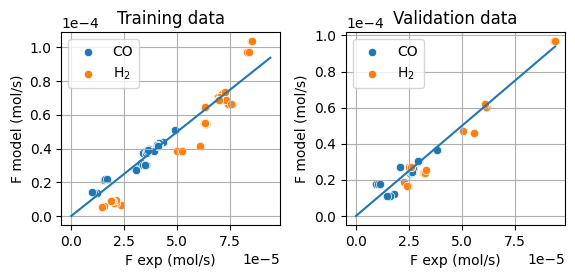

In [16]:
fig, axs = plt.subplots(1,2, figsize=(6.5,2.5))
plt.subplots_adjust(hspace=0.4, wspace = 0.3)
max_xy = max(kinetic_data.F_CO_s_mol_s.max(), kinetic_data.F_H2_s_mol_s.max())

sns.scatterplot(
                data=kinetic_data.loc[kinetic_data.training], 
                x='F_CO_s_mol_s', 
                y='F_CO_out_hysys', 
                ax = axs[0],
                label = 'CO',
)

sns.scatterplot(
                data=kinetic_data.loc[kinetic_data.training], 
                x='F_H2_s_mol_s', 
                y='F_H2_out_hysys', 
                ax = axs[0],
                label = r'$\mathrm{H_2}$',
)

axs[0].plot((0, max_xy), (0, max_xy))
axs[0].set_title('Training data')
axs[0].set_xlabel('F exp (mol/s)')
axs[0].set_ylabel('F model (mol/s)')
axs[0].grid('both')
axs[0].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

sns.scatterplot(
                data=kinetic_data.loc[~kinetic_data.training], 
                x='F_CO_s_mol_s', 
                y='F_CO_out_hysys', 
                ax = axs[1],
                label = 'CO',
)

sns.scatterplot(
                data=kinetic_data.loc[~kinetic_data.training], 
                x='F_H2_s_mol_s', 
                y='F_H2_out_hysys', 
                ax = axs[1],
                label = r'$\mathrm{H_2}$',
)

axs[1].plot((0, max_xy), (0, max_xy))
axs[1].set_title('Validation data')
axs[1].set_xlabel('F exp (mol/s)')
axs[1].set_ylabel('F model (mol/s)')
axs[1].grid('both')
axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

plt.savefig(f'{fig_path}parity_hysys.pdf', bbox_inches = 'tight')

In [18]:
F0 = kinetic_data['F_H2_e_mol_s'] + kinetic_data['F_CO_e_mol_s']

In [19]:
F0.min()

np.float64(0.0001051922791958425)

In [20]:
F0.max()

np.float64(0.0001698886298367094)